In [2]:
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [3]:
def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Can Return two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # Create smoothed version
            ntwk_smooth = smooth_network(ntwk, window, poly)
            ntwk_smooth.name = name

            smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_measured"] = original_list
    globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list, smoothed_list


def avg_return_loss(ntwk):
    s11_db = ntwk.s_db[:,0,0]
    return np.mean(s11_db)
def worst_return_loss(ntwk):
    return np.max(ntwk.s_db[:640,0,0])   # closest to 0 dB
def avg_transmit_loss(ntwk):
    s11_db = ntwk.s_db[:,1,0]
    return np.mean(s11_db)
def worst_transmit_loss(ntwk):
    return np.max(ntwk.s_db[:,1,0])   # closest to 0 dB

# COMPARISON BETWEEN reflection ans trasmission of FCB02 FCB02 B2

In [4]:
thru_26um_measured, thru_26um_smoothened = load_directory(r'Samples\FCB02\GEECI_mes\SetC\SUB3', window=36, poly=2)
thru_176um_measured, thru_176um_smoothened = load_directory(r'Samples\FCB02_B2\GEECI_meas_18min_21_may_2026\SUB3\SETA', window=36, poly=2)

In [5]:
thru_26um_smoothened[-3:]

[2-Port Network: 'thru_ref_nos1',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'thru_ref_nos2',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'thru_ref_nos3',  1000000000.0-45000000000.0 Hz, 441 pts, z0=[50.+0.j 50.+0.j]]

Loading data from: Samples\FCB02_B2\GEECI_meas_18min_21_may_2026\S_param.txt


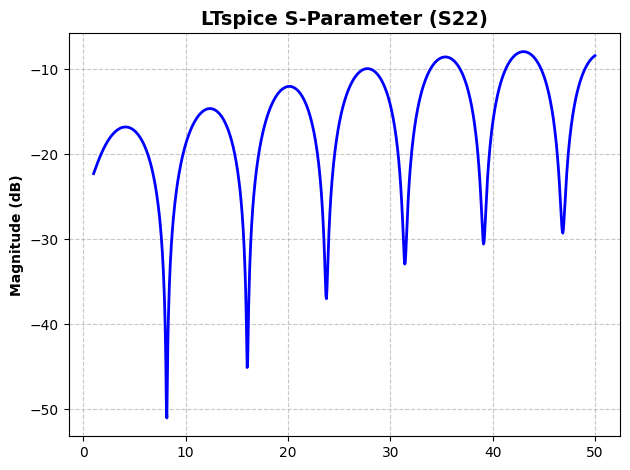

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ltspice_sparam(file_path):
    freqs = []
    mags = []
    phases = []

    print(f"Loading data from: {file_path}")
    
    with open(file_path, 'r', encoding='latin-1') as f:
        # Read all lines
        lines = f.readlines()

    # Loop through lines, skipping the first (header) line
    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue
            
        # LTspice usually separates columns by a Tab
        columns = line.split('\t')
        if len(columns) < 2:
            columns = line.split() # Fallback to general whitespace split
            
        if len(columns) >= 2:
            freq_str = columns[0]
            s_str = columns[1]
            
            # The S-parameter string looks like: (-2.469e+01dB,-3.043e+01°)
            # 1. Remove the opening and closing parentheses
            s_str_clean = s_str.replace('(', '').replace(')', '')
            
            # 2. Split into magnitude and phase using the comma
            mag_str, phase_str = s_str_clean.split(',')
            
            # 3. Remove the 'dB' and '°' text characters, then convert to float
            mag = float(mag_str.replace('dB', ''))
            phase = float(phase_str.replace('°', ''))
            freq = float(freq_str)
            
            freqs.append(freq)
            mags.append(mag)
            phases.append(phase)

    # Convert lists to NumPy arrays for easy math
    # Convert frequency to GHz for a cleaner X-axis
    freqs_GHz = np.array(freqs) / 1e9 
    mags = np.array(mags)
    phases = np.array(phases)

    # ---------------------------------------------------------
    # Plotting the Data
    # ---------------------------------------------------------


    # Top Plot: Magnitude (dB)
    plt.plot(freqs_GHz, mags, color='blue', linewidth=2)
    plt.ylabel('Magnitude (dB)', fontweight='bold')
    plt.title('LTspice S-Parameter (S22)', fontsize=14, fontweight='bold')
    plt.grid(True, which='both', linestyle='--', alpha=0.7)

    # # Bottom Plot: Phase (Degrees)
    # ax2.plot(freqs_GHz, phases, color='red', linewidth=2)
    # ax2.set_ylabel('Phase (Degrees)', fontweight='bold')
    # ax2.set_xlabel('Frequency (GHz)', fontweight='bold')
    # ax2.grid(True, which='both', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# ==========================================
# Run the function
# ==========================================
# Replace this string with the actual path to your LTspice export text file
file_directory = r'Samples\FCB02_B2\GEECI_meas_18min_21_may_2026\S_param.txt'

plot_ltspice_sparam(file_directory)

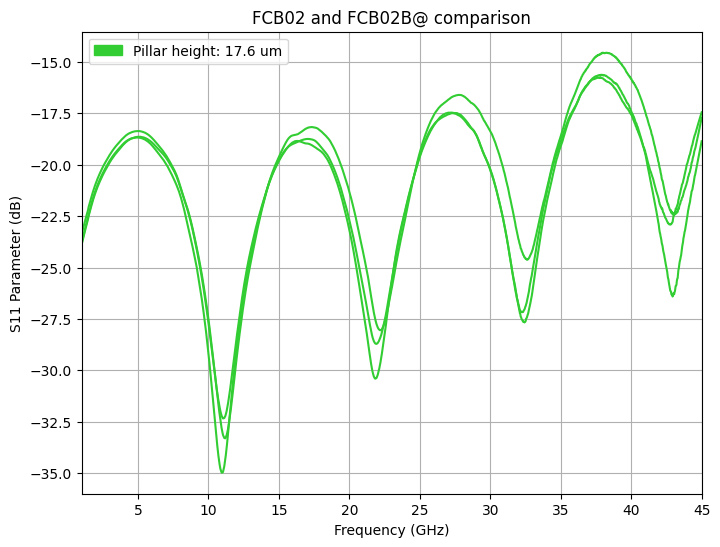

In [8]:
import matplotlib.patches as mpatches
ntwk26 = []
ntwk176 = []
plt.figure(figsize=(8, 6))

# for ntwk in thru_26um_smoothened[-3:]:  # Example: plot first 5 networks
#     ntwk26.append(ntwk)
#     ntwk.frequency.unit = 'GHz'
#     ntwk.plot_s_db(m=0,n=0, color='royalblue')    # 4. Plot the data
# royalblue_patch = mpatches.Patch(color='royalblue', label='Pillar height: 2.6 um')
    
for ntwk in thru_176um_smoothened[:3]:  # Example: plot first 5 networks
    ntwk176.append(ntwk)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0, n=0, color='limegreen', label="17um thru standard")    # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='Pillar height: 17.6 um')

plt.grid(True)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 Parameter (dB)')
plt.title('FCB02 and FCB02B@ comparison')
# plt.xlim(15e9, 45e9)  # Set x-axis limits to focus on 0-20 GHz
# plt.ylim(-50, 1)    # Set y-axis limits to focus on -30 to 0 dB
plt.legend(handles=[ limegreen_patch])


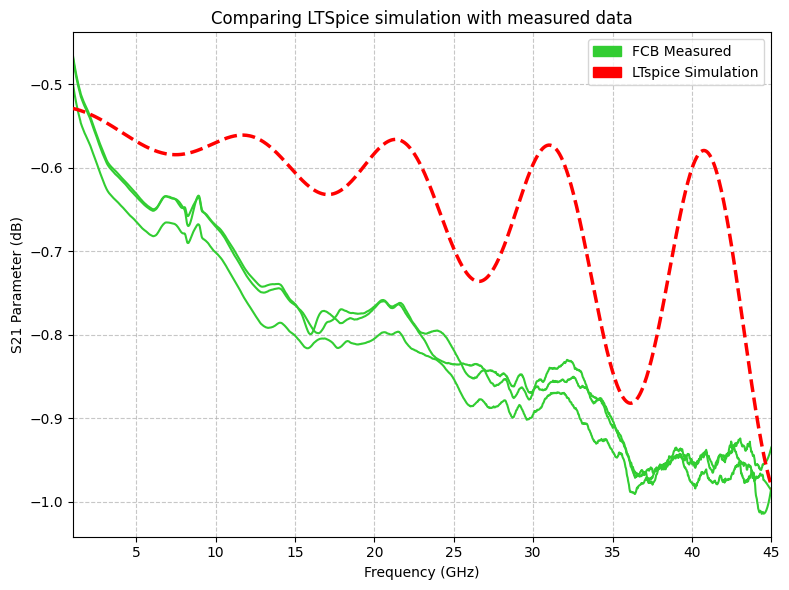

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---------------------------------------------------------
# 1. Helper Function to Parse LTspice Text File
# ---------------------------------------------------------
def read_ltspice_s_param(file_path):
    freqs_GHz = []
    mags_dB = []
    
    # Using 'latin-1' to safely bypass the degree (°) symbol error
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
        
    for line in lines[1:]:
        line = line.strip()
        if not line: continue
            
        cols = line.split('\t') if '\t' in line else line.split()
        if len(cols) >= 2:
            freq = float(cols[0])
            s_str = cols[1].replace('(', '').replace(')', '')
            mag_str, _ = s_str.split(',')
            
            freqs_GHz.append(freq
            ) # Convert to GHz to match skrf
            mags_dB.append(float(mag_str.replace('dB', '')))
            
    return freqs_GHz, mags_dB

# ---------------------------------------------------------
# 2. Main Plotting Script
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# --- Plot LTspice Data ---
# UPDATE THIS STRING WITH YOUR ACTUAL FILE PATH
ltspice_file = r'Samples\FCB02_B2\GEECI_meas_18min_21_may_2026\S21_param_.txt'
sim_freqs, sim_mags = read_ltspice_s_param(ltspice_file)

# Plot LTspice data (using dashed red line to distinguish it from measurements)
plt.plot(sim_freqs, sim_mags, color='red', linestyle='--', linewidth=2.5, zorder=5)
ltspice_patch = mpatches.Patch(color='red', label='LTspice Simulation')


# --- Plot 26um Measurement Data (Currently Commented Out) ---
ntwk26 = []
# for ntwk in thru_26um_smoothened[-3:]:  
#     ntwk26.append(ntwk)
#     ntwk.frequency.unit = 'GHz'
#     ntwk.plot_s_db(m=0,n=0, color='royalblue')    
# royalblue_patch = mpatches.Patch(color='royalblue', label='Pillar height: 2.6 um')
    

# --- Plot 17um Measurement Data ---
ntwk176 = []
for ntwk in thru_176um_smoothened[:3]:  
    ntwk.frequency.unit = 'GHz'
    # Plotting skrf networks (zorder=4 ensures they sit under/over the sim line predictably)
    ntwk.plot_s_db(m=1, n=0, color='limegreen')    
limegreen_patch = mpatches.Patch(color='limegreen', label='FCB Measured')


# ---------------------------------------------------------
# 3. Graph Formatting
# ---------------------------------------------------------
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 Parameter (dB)')
plt.title('Comparing LTSpice simulation with measured data')
plt.xlim(1e9,45e9)
# Add all three patches to the legend
plt.legend(handles=[ limegreen_patch, ltspice_patch])

# plt.xlim(15, 45)  # Set x-axis limits (Now in GHz, NOT Hz!)
# plt.ylim(-50, 1)  # Set y-axis limits to focus on -30 to 0 dB

plt.tight_layout()
plt.show()

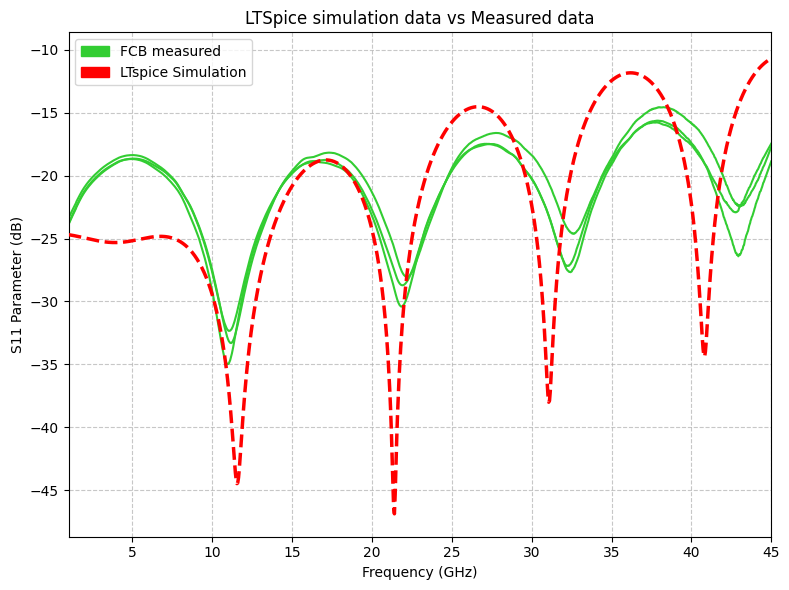

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---------------------------------------------------------
# 1. Helper Function to Parse LTspice Text File
# ---------------------------------------------------------
def read_ltspice_s_param(file_path):
    freqs_GHz = []
    mags_dB = []
    
    # Using 'latin-1' to safely bypass the degree (°) symbol error
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
        
    for line in lines[1:]:
        line = line.strip()
        if not line: continue
            
        cols = line.split('\t') if '\t' in line else line.split()
        if len(cols) >= 2:
            freq = float(cols[0])
            s_str = cols[1].replace('(', '').replace(')', '')
            mag_str, _ = s_str.split(',')
            
            freqs_GHz.append(freq
            ) # Convert to GHz to match skrf
            mags_dB.append(float(mag_str.replace('dB', '')))
            
    return freqs_GHz, mags_dB

# ---------------------------------------------------------
# 2. Main Plotting Script
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# --- Plot LTspice Data ---
# UPDATE THIS STRING WITH YOUR ACTUAL FILE PATH
ltspice_file = r'Samples\FCB02_B2\GEECI_meas_18min_21_may_2026\S_param_.txt'
sim_freqs, sim_mags = read_ltspice_s_param(ltspice_file)

# Plot LTspice data (using dashed red line to distinguish it from measurements)
plt.plot(sim_freqs, sim_mags, color='red', linestyle='--', linewidth=2.5, zorder=5)
ltspice_patch = mpatches.Patch(color='red', label='LTspice Simulation')


# --- Plot 26um Measurement Data (Currently Commented Out) ---
ntwk26 = []
# for ntwk in thru_26um_smoothened[-3:]:  
#     ntwk26.append(ntwk)
#     ntwk.frequency.unit = 'GHz'
#     ntwk.plot_s_db(m=0,n=0, color='royalblue')    
royalblue_patch = mpatches.Patch(color='royalblue', label='Pillar height: 2.6 um')
    

# --- Plot 17um Measurement Data ---
ntwk176 = []
for ntwk in thru_176um_smoothened[:3]:  
    ntwk176.append(ntwk)
    ntwk.frequency.unit = 'GHz'
    # Plotting skrf networks (zorder=4 ensures they sit under/over the sim line predictably)
    ntwk.plot_s_db(m=0, n=0, color='limegreen')    
limegreen_patch = mpatches.Patch(color='limegreen', label='FCB measured')


# ---------------------------------------------------------
# 3. Graph Formatting
# ---------------------------------------------------------
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 Parameter (dB)')
plt.title('LTSpice simulation data vs Measured data')
plt.xlim(1e9,45e9)
# Add all three patches to the legend
plt.legend(handles=[ limegreen_patch, ltspice_patch])

# plt.xlim(15, 45)  # Set x-axis limits (Now in GHz, NOT Hz!)
# plt.ylim(-50, 1)  # Set y-axis limits to focus on -30 to 0 dB

plt.tight_layout()
plt.show()

2-Port Network: 'thru1',  1.0-45.0 GHz, 1601 pts, z0=[50.+0.j 50.+0.j]
2-Port Network: 'thru2',  1.0-45.0 GHz, 1601 pts, z0=[50.+0.j 50.+0.j]
2-Port Network: 'thru3',  1.0-45.0 GHz, 1601 pts, z0=[50.+0.j 50.+0.j]
2-Port Network: 'thru_ref_nos1',  1.0-45.0 GHz, 441 pts, z0=[50.+0.j 50.+0.j]
2-Port Network: 'thru_ref_nos2',  1.0-45.0 GHz, 441 pts, z0=[50.+0.j 50.+0.j]
2-Port Network: 'thru_ref_nos3',  1.0-45.0 GHz, 441 pts, z0=[50.+0.j 50.+0.j]


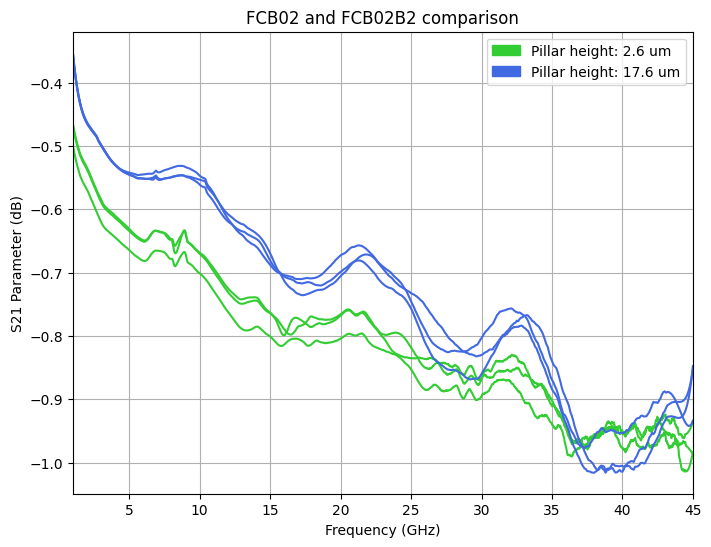

In [14]:
import matplotlib.patches as mpatches


plt.figure(figsize=(8, 6))

for ntwk in thru_176um_smoothened[:3]:  # Example: plot first 5 networks
    print(ntwk)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1, n=0, color='limegreen', label="17um thru standard")    # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='Pillar height: 2.6 um')

for ntwk in thru_26um_smoothened[-3:]:  # Example: plot first 5 networks
    print(ntwk)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0, color='royalblue')    # 4. Plot the data
royalblue_patch = mpatches.Patch(color='royalblue', label='Pillar height: 17.6 um')
    



plt.grid(True)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 Parameter (dB)')
plt.title('FCB02 and FCB02B2 comparison')
# plt.xlim(15e9, 45e9)  # Set x-axis limits to focus on 0-20 GHz
# plt.ylim(-50, 1)    # Set y-axis limits to focus on -30 to 0 dB
plt.legend(handles=[limegreen_patch,royalblue_patch])


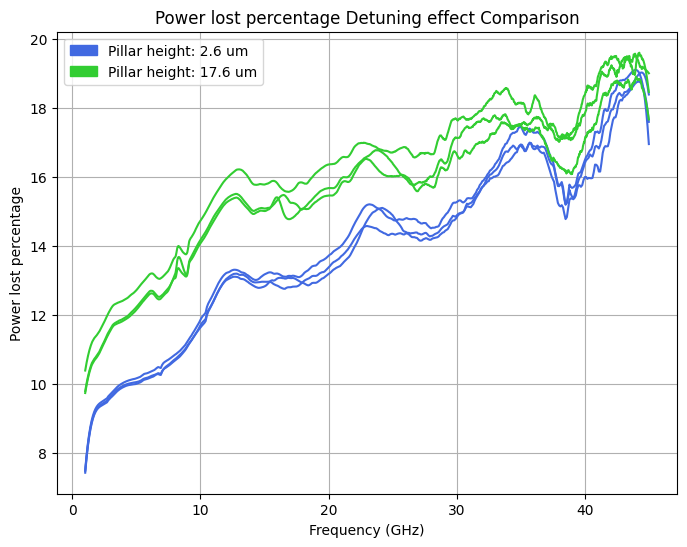

In [ ]:
plt.figure(figsize=(8, 6))

for ntwk in thru_26um_smoothened[-3:]:  # Example: plot first 5 networks
    ntwk.frequency.unit = 'GHz'
    s11 = ntwk.s_mag[:, 0, 0]  # Extract S11
    s21 = ntwk.s_mag[:, 1, 0]  # Extract S21
    lost_power_fraction = [100 * (1-(x*x +y*y)) for x, y in zip(s11, s21)]
    plt.plot(ntwk.frequency.f/1e9, lost_power_fraction, color='royalblue')
royalblue_patch = mpatches.Patch(color='royalblue', label='Pillar height: 2.6 um')
    
for ntwk in thru_176um_smoothened[:3]:  # Example: plot first 5 networks
    ntwk.frequency.unit = 'GHz'
    s11 = ntwk.s_mag[:, 0, 0]  # Extract S11
    s21 = ntwk.s_mag[:, 1, 0]  # Extract S21
    lost_power_fraction = [100 * (1-(x*x +y*y)) for x, y in zip(s11, s21)]
    plt.plot(ntwk.frequency.f/1e9, lost_power_fraction, color='limegreen')
limegreen_patch = mpatches.Patch(color='limegreen', label='Pillar height: 17.6 um')

plt.xlabel("Frequency (GHz)")
plt.ylabel("Power lost percentage")
plt.title("Power lost percentage Detuning effect Comparison")
plt.grid(True)
plt.legend(handles=[royalblue_patch, limegreen_patch])
plt.savefig('power_lost_percent_Detuning_effect_comparison.png', dpi=300)

# Detuning effect in FCB02

In [ ]:
thru_26um_measured, thru_26um_smoothened = load_directory(r'Samples\FCB02\GEECI_mes\SetC\SUB3', window=36, poly=2)
thru_covered_26um_measured, thru_covered_26um_smoothened = load_directory(r'Samples\FCB02\GEECI_mes\SetC\SUB4(DMD)', window=36, poly=2)
thru_covered_26um_measured_, thru_covered_26um_smoothened_ = load_directory(r'Samples\FCB02\GEECI_mes\SetB\SUB4(DMD)', window=36, poly=2)

TN2
TN6


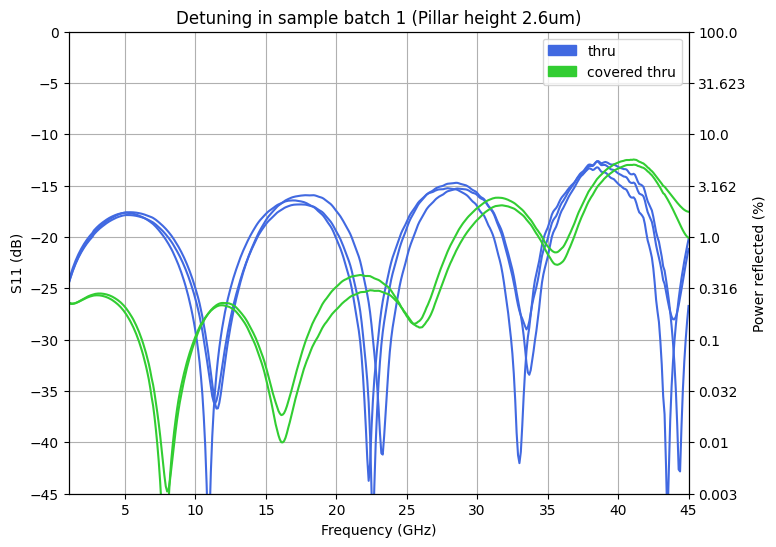

In [ ]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 6))
ax1 = plt.gca()
plt.grid(True)

for ntwk in thru_26um_smoothened[-3:]:  # Example: plot first 5 networks
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, color='royalblue')    # 4. Plot the data
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')

for ntwk in thru_covered_26um_smoothened_[:2]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0, n=0, color='limegreen')    # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

plt.legend(handles=[royalblue_patch, limegreen_patch])
# --- SET Y-AXIS LIMITS HERE ---
ax1.set_ylabel("S11 (dB)")
plt.ylim(-45,0)

# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')
plt.xlabel('Frequency (GHz)')
plt.title('Detuning in sample batch 1 (Pillar height 2.6um)')

plt.savefig('S11_Detuning_effect_fcb02_b1.png', dpi=300)


TN2
TN6


<Figure size 800x600 with 0 Axes>

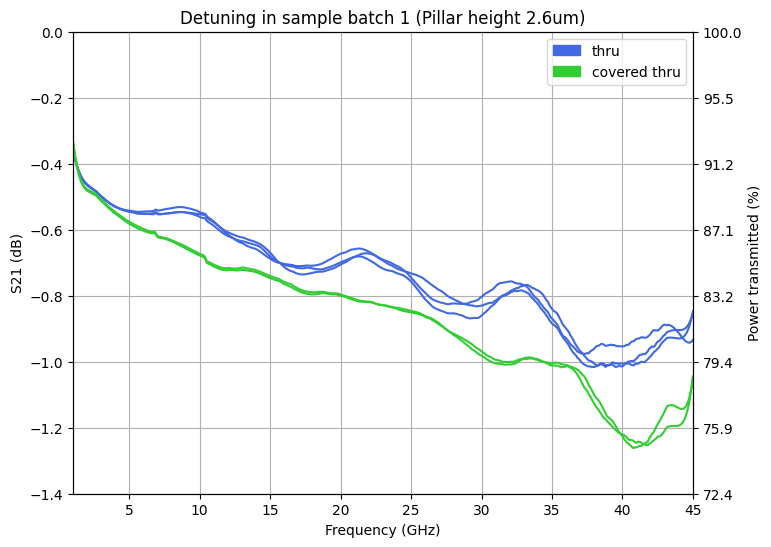

In [ ]:
import matplotlib.patches as mpatches
ntwk26 = []
ntwk176 = []
plt.figure(figsize=(8, 6))
plt.figure(figsize=(8, 6))
ax1 = plt.gca()
plt.grid(True)


for ntwk in thru_26um_smoothened[-3:]:  # Example: plot first 5 networks
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0, color='royalblue')    # 4. Plot the data
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')
    
for ntwk in thru_covered_26um_smoothened_[:2]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1, n=0, color='limegreen')    # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

plt.legend(handles=[royalblue_patch, limegreen_patch])
# --- SET Y-AXIS LIMITS HERE ---
ax1.set_ylabel("S21 (dB)")
plt.ylim(-1.40,0)

# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 1) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power transmitted (%)')
plt.xlabel('Frequency (GHz)')
plt.title('Detuning in sample batch 1 (Pillar height 2.6um)')
plt.savefig('S21_Detuning_effect_fcb02_b1.png', dpi=300)


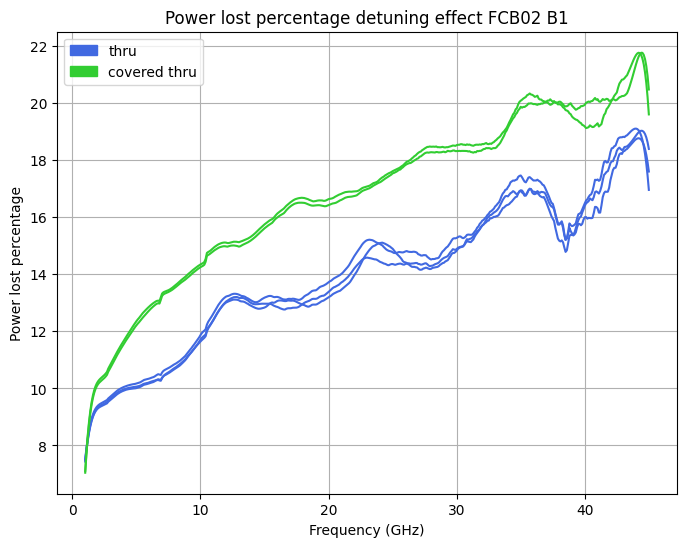

In [ ]:
plt.figure(figsize=(8, 6))

for ntwk in thru_26um_smoothened[-3:]:  # Example: plot first 5 networks
    ntwk.frequency.unit = 'GHz'
    s11 = ntwk.s_mag[:, 0, 0]  # Extract S11
    s21 = ntwk.s_mag[:, 1, 0]  # Extract S21
    lost_power_fraction = [100 * (1-(x*x +y*y)) for x, y in zip(s11, s21)]
    plt.plot(ntwk.frequency.f/1e9, lost_power_fraction, color='royalblue')
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')
    
for ntwk in thru_covered_26um_smoothened_[:2]:  # Example: plot first 5 networks
    ntwk.frequency.unit = 'GHz'
    s11 = ntwk.s_mag[:, 0, 0]  # Extract S11
    s21 = ntwk.s_mag[:, 1, 0]  # Extract S21
    lost_power_fraction = [100 * (1-(x*x +y*y)) for x, y in zip(s11, s21)]
    plt.plot(ntwk.frequency.f/1e9, lost_power_fraction, color='limegreen')
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

plt.xlabel("Frequency (GHz)")
plt.ylabel("Power lost percentage")
plt.title("Power lost percentage detuning effect FCB02 B1")
plt.grid(True)
plt.legend(handles=[royalblue_patch, limegreen_patch])
plt.savefig('power_lost_percent_Detuning_effect_fcb02_b1.png', dpi=300)

thru_ref_nos1
thru_ref_nos2
thru_ref_nos3
TN2
TN6


c:\Users\hrith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\hrith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


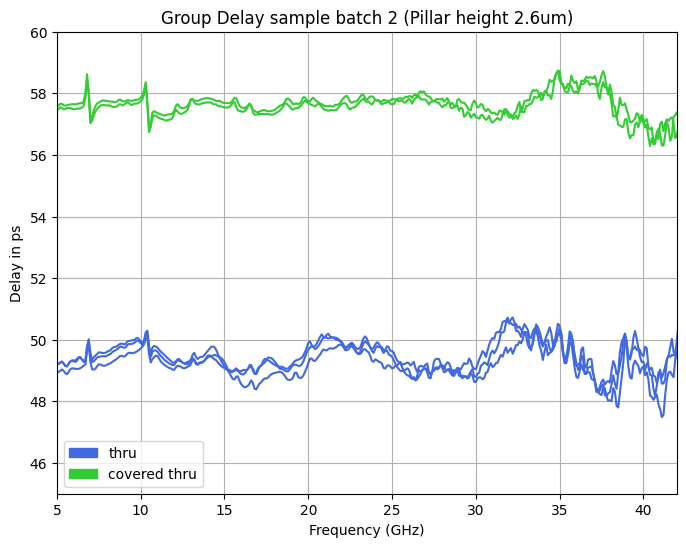

In [ ]:

plt.figure(figsize=(8, 6))
plt.grid(True)
for ntwk in thru_26um_smoothened[-3:]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot(ntwk.s21.group_delay * 1e12,color='royalblue')    # 4. Plot the data
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')

for ntwk in thru_covered_26um_smoothened_[:2]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot(ntwk.s21.group_delay * 1e12,color='limegreen')    # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

plt.xlim(5e9,42e9)
plt.xlabel('Frequency (GHz)')
plt.ylabel("Delay in ps")
plt.ylim(45,60)

plt.legend(handles=[royalblue_patch, limegreen_patch])
plt.title('Group Delay sample batch 2 (Pillar height 2.6um)')

plt.savefig('Group_delay_fcb02_b1.png', dpi=300)


# Detuning effect in FCB02 B2

In [ ]:
thru_176um_measured, thru_176um_smoothened = load_directory(r'Samples\FCB02_B2\GEECI_meas_18min_21_may_2026\SUB3\SETA', window=86, poly=3)
thru_covered_176um_measured, thru_covered_176um_smoothened = load_directory(r'Samples\FCB02_B2\GEECI_meas_18min_21_may_2026\DMD\SETB_excluded_meas', window=86, poly=3)

thru1
thru2
thru3
floating_die_tn4
floating_die_tn5
floating_die_tn6


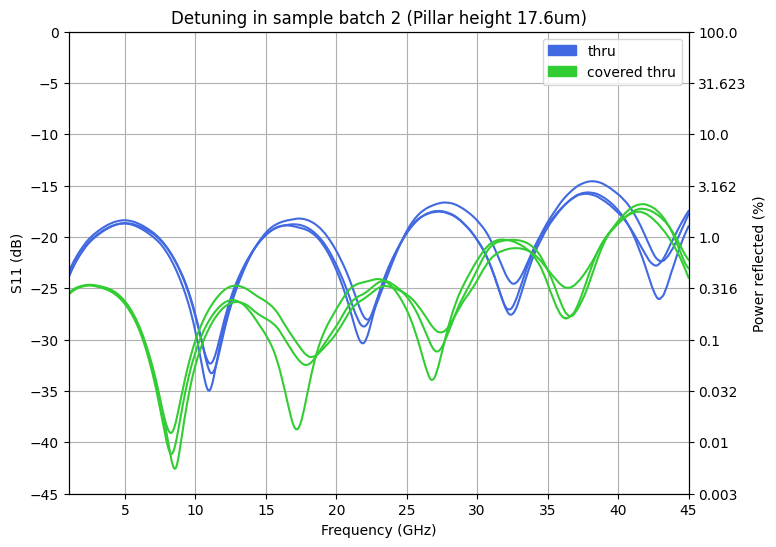

In [ ]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 6))
ax1 = plt.gca()
plt.grid(True)

for ntwk in thru_176um_smoothened[:3]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, color='royalblue')    # 4. Plot the data
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')

for ntwk in thru_covered_176um_smoothened[:3]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0, n=0, color='limegreen')    # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

plt.legend(handles=[royalblue_patch, limegreen_patch])
# --- SET Y-AXIS LIMITS HERE ---
ax1.set_ylabel("S11 (dB)")
plt.ylim(-45,0)

# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')
plt.xlabel('Frequency (GHz)')
plt.title('Detuning in sample batch 2 (Pillar height 17.6um)')

plt.savefig('S11_Detuning_effect_fcb02_b2.png', dpi=300)


thru1
thru2
thru3
floating_die_tn4
floating_die_tn5
floating_die_tn6


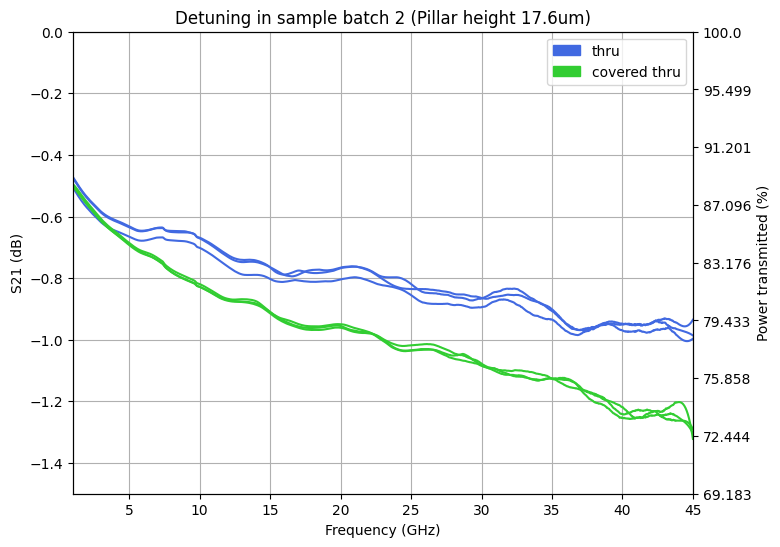

In [ ]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 6))
ax1 = plt.gca()
plt.grid(True)

for ntwk in thru_176um_smoothened[:3]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0, color='royalblue')    # 4. Plot the data
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')

for ntwk in thru_covered_176um_smoothened[:3]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1, n=0, color='limegreen')    # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

plt.legend(handles=[royalblue_patch, limegreen_patch])
# --- SET Y-AXIS LIMITS HERE ---
ax1.set_ylabel("S21 (dB)")
plt.ylim(-1.5,0)

# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power transmitted (%)')
plt.xlabel('Frequency (GHz)')
plt.title('Detuning in sample batch 2 (Pillar height 17.6um)')

plt.savefig('S21_Detuning_effect_fcb02_b2.png', dpi=300)


thru1
thru2
thru3
floating_die_tn4
floating_die_tn5
floating_die_tn6


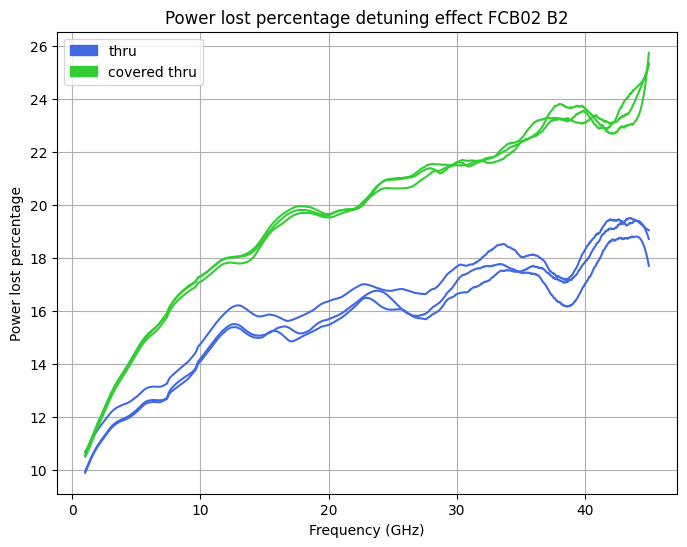

In [ ]:
plt.figure(figsize=(8, 6))

for ntwk in thru_176um_smoothened[:3]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    s11 = ntwk.s_mag[:, 0, 0]  # Extract S11
    s21 = ntwk.s_mag[:, 1, 0]  # Extract S21
    lost_power_fraction = [100 * (1-(x*x +y*y)) for x, y in zip(s11, s21)]
    plt.plot(ntwk.frequency.f/1e9, lost_power_fraction, color='royalblue')
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')
    
for ntwk in thru_covered_176um_smoothened[:3]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    s11 = ntwk.s_mag[:, 0, 0]  # Extract S11
    s21 = ntwk.s_mag[:, 1, 0]  # Extract S21
    lost_power_fraction = [100 * (1-(x*x +y*y)) for x, y in zip(s11, s21)]
    plt.plot(ntwk.frequency.f/1e9, lost_power_fraction, color='limegreen')
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

plt.xlabel("Frequency (GHz)")
plt.ylabel("Power lost percentage")
plt.title("Power lost percentage detuning effect FCB02 B2")
plt.grid(True)
plt.legend(handles=[royalblue_patch, limegreen_patch])
plt.savefig('power_lost_percent_Detuning_effect_fcb02_b2.png', dpi=300)

thru1
floating_die_tn4


c:\Users\hrith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\hrith\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


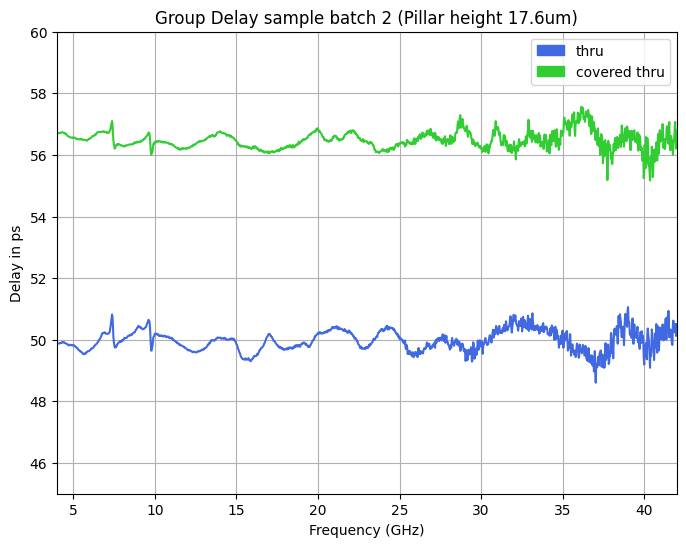

In [ ]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 6))
ax1 = plt.gca()
plt.grid(True)

for ntwk in thru_176um_smoothened[:1]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot(ntwk.s21.group_delay * 1e12,color='royalblue')    # 4. Plot the data
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')

for ntwk in thru_covered_176um_smoothened[:1]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot(ntwk.s21.group_delay * 1e12,color='limegreen')    # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

plt.xlim(4e9,42e9)
plt.xlabel('Frequency (GHz)')

plt.ylabel("Delay in ps")
plt.ylim(45,60)

plt.legend(handles=[royalblue_patch, limegreen_patch])
plt.title('Group Delay sample batch 2 (Pillar height 17.6um)')
plt.savefig('Group_delay_fcb02_b2.png', dpi=300)


thru1
floating_die_tn4


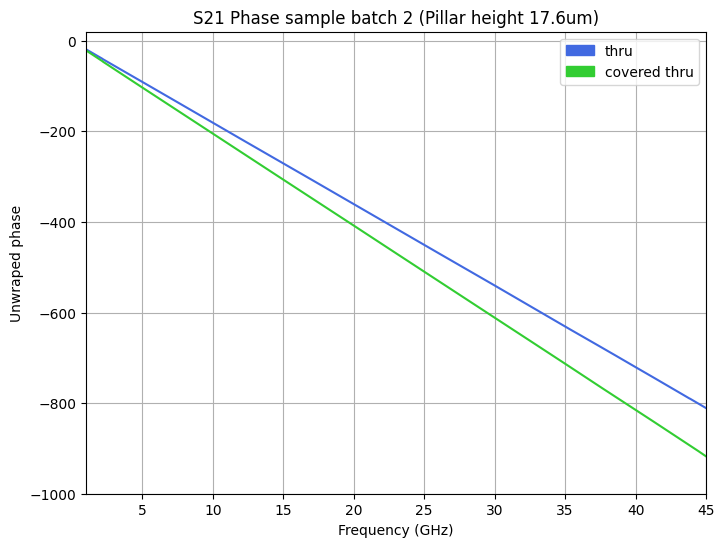

In [ ]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 6))
ax1 = plt.gca()
plt.grid(True)

for ntwk in thru_176um_smoothened[:1]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_deg_unwrap(1, 0, label='S21 Phase of thru (Wrapped)',color='royalblue')    # 4. Plot the data
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')

for ntwk in thru_covered_176um_smoothened[:1]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_deg_unwrap(1, 0, label='S21 Phase of covered (Wrapped)', color='limegreen')   # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

# plt.xlim(2e9,42e9)
plt.xlabel('Frequency (GHz)')

plt.ylabel("Unwraped phase")
plt.ylim(-1000,20)

plt.legend(handles=[royalblue_patch, limegreen_patch])
plt.title('S21 Phase sample batch 2 (Pillar height 17.6um)')
plt.savefig('S21phase_fcb02_b2.png', dpi=300)


thru1
floating_die_tn4


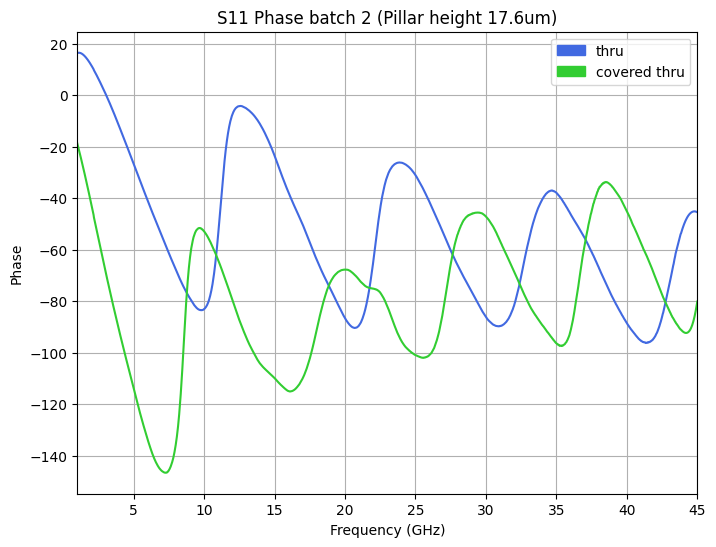

In [ ]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8, 6))
ax1 = plt.gca()
plt.grid(True)

for ntwk in thru_176um_smoothened[:1]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_deg_unwrap(0, 0, label='S11 Phase of thru (Wrapped)', color='royalblue')    # 4. Plot the data
royalblue_patch = mpatches.Patch(color='royalblue', label='thru')

for ntwk in thru_covered_176um_smoothened[:1]:  # Example: plot first 5 networks
    print(ntwk.name)
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_deg_unwrap(0, 0, label='S11 Phase of covered (Wrapped)', color='limegreen')   # 4. Plot the data
limegreen_patch = mpatches.Patch(color='limegreen', label='covered thru')

# plt.xlim(2e9,42e9)
plt.xlabel('Frequency (GHz)')

plt.ylabel("Phase")
# plt.ylim(-200,200)

plt.legend(handles=[royalblue_patch, limegreen_patch])
plt.title('S11 Phase batch 2 (Pillar height 17.6um)')
plt.savefig('S11 phase_fcb02_b2.png', dpi=300)
